In [1]:
import networkx as nx
import xml.etree.ElementTree as ET
import numpy as np
from helper_functions import l2_norm

#### Creation of graph

- graph is built with use of [yEd Live](https://www.yworks.com/yed-live/)
- coordinates refer to the upper left edge of a node
- lanes, i.e., the edges of the graph, are directed in order to reduce the likelihood of collisions
- lanes are shifted towards one side of shelves to facilitate passing maneuvers
- shelves are positioned with a certain distance to the walls to allow robots accessing the shelves without triggering large collision costs caused by walls behind the shelves

#### Read in graph

In [21]:
G = nx.read_graphml("../data/warehouse/Warehouse.graphml")

/home/itm/iwenger/.venv/venv_lab/lib/python3.10/site-packages/networkx/readwrite/graphml.py:1034: UserWarning: No key type for id d4. Using string
  warnings.warn(f"No key type for id {attr_id}. Using string")
/home/itm/iwenger/.venv/venv_lab/lib/python3.10/site-packages/networkx/readwrite/graphml.py:1034: UserWarning: No key type for id d5. Using string
  warnings.warn(f"No key type for id {attr_id}. Using string")
/home/itm/iwenger/.venv/venv_lab/lib/python3.10/site-packages/networkx/readwrite/graphml.py:1034: UserWarning: No key type for id d6. Using string
  warnings.warn(f"No key type for id {attr_id}. Using string")
/home/itm/iwenger/.venv/venv_lab/lib/python3.10/site-packages/networkx/readwrite/graphml.py:1034: UserWarning: No key type for id d7. Using string
  warnings.warn(f"No key type for id {attr_id}. Using string")
/home/itm/iwenger/.venv/venv_lab/lib/python3.10/site-packages/networkx/readwrite/graphml.py:1034: UserWarning: No key type for id d8. Using string
  warnings.wa

#### Preprocessing

- positions are represented in metres (see scaling)
- the scaling is chosen such that robots can pass each other on the lanes and such that a robot moving close to maximum speed is able to follow sharp curves and access a shelf without being likely to collide with another object

In [22]:
# Parse the GraphML file directly for geometry info
tree = ET.parse("../data/warehouse/Warehouse.graphml")
scale = 2.2 / 100
for node in tree.getroot().findall(
    ".//graphml:node",
    {
        "graphml": "http://graphml.graphdrawing.org/xmlns",
    },
):
    node_id = node.attrib["id"]
    rect = node.find(".//y:RectD", {"y": "http://www.yworks.com/xml/yfiles-common/3.0"})
    G.nodes[node_id]["x"] = float(rect.attrib["X"]) * scale
    G.nodes[node_id]["y"] = float(rect.attrib["Y"]) * scale
    G.nodes[node_id]["width"] = float(rect.attrib["Width"]) * scale
    G.nodes[node_id]["height"] = float(rect.attrib["Height"]) * scale

#### Sort nodes into categories

In [23]:
shelves = []
waypoints = []
delivery = []
machines = []
doors = []
charging_stations = []
walls = []

for node_id in G.nodes:

    if "description" in G.nodes[node_id]:
        if G.nodes[node_id]["description"] == "machine":
            machines.append(node_id)
        elif G.nodes[node_id]["description"] == "delivery":
            delivery.append(node_id)
        elif G.nodes[node_id]["description"] == "door":
            doors.append(node_id)
        elif G.nodes[node_id]["description"] == "shelf":
            shelves.append(node_id)
        elif G.nodes[node_id]["description"] == "charging station":
            charging_stations.append(node_id)
        elif G.nodes[node_id]["description"] == "wall":
            walls.append(node_id)
        elif G.nodes[node_id]["description"] == "waypoint" and G.adj[node_id] != {}:
            waypoints.append(node_id)
    else:
        print(f"Uncategorized node: {node_id, G.nodes[node_id]}")

    G.nodes[node_id].pop("zOrder")

In [24]:
len(waypoints), len(shelves)

(75, 176)

In [25]:
G.nodes(data=True)

NodeDataView({'n0': {'description': 'shelf', 'x': 8.49326970050681, 'y': 4.962214223250029, 'width': 0.66, 'height': 0.66}, 'n1': {'description': 'shelf', 'x': 7.877458444696079, 'y': 6.9465, 'width': 0.66, 'height': 0.66}, 'n2': {'description': 'shelf', 'x': 3.2132697005068094, 'y': 4.962214223250029, 'width': 0.66, 'height': 0.66}, 'n3': {'description': 'waypoint', 'x': 2.7246459446960833, 'y': 3.9036250000000003, 'width': 0.11000000000000001, 'height': 0.11000000000000001}, 'n4': {'description': 'waypoint', 'x': 9.755519700506795, 'y': 3.8871250000000006, 'width': 0.11000000000000001, 'height': 0.11000000000000001}, 'n5': {'description': 'shelf', 'x': 7.8332697005068095, 'y': 4.962214223250029, 'width': 0.66, 'height': 0.66}, 'n6': {'description': 'shelf', 'x': 8.537458444696078, 'y': 6.9465, 'width': 0.66, 'height': 0.66}, 'n7': {'description': 'shelf', 'x': 7.173269700506809, 'y': 4.962214223250029, 'width': 0.66, 'height': 0.66}, 'n8': {'description': 'shelf', 'x': 4.533269700506

In [26]:
G.nodes(data=True)[shelves[0]]

{'description': 'shelf',
 'x': 8.49326970050681,
 'y': 4.962214223250029,
 'width': 0.66,
 'height': 0.66}

In [27]:
max([G.nodes(data=True)[n]["x"] for n in G.nodes])

29.455249999999968

#### Add the euclidean distances between nodes to the edges, add edges as Shapely lines

In [28]:
from src.deployment_area.voronoi_helpers import l2_norm
import numpy as np

In [29]:
def get_coords(node_id):
    data = G.nodes[node_id]
    return np.array([data["x"], data["y"]])

In [30]:
for n1, n2 in G.edges:

    G.edges[n1, n2]["eucl_dist"] = l2_norm(get_coords(n1) - get_coords(n2))

In [31]:
G.edges(data=True)

OutEdgeDataView([('n3', 'n74', {'id': 'e6', 'eucl_dist': np.float32(2.64)}), ('n3', 'n22', {'id': 'e8', 'eucl_dist': np.float32(3.0942926)}), ('n4', 'n75', {'id': 'e3', 'eucl_dist': np.float32(1.3200009)}), ('n4', 'n76', {'id': 'e4', 'eucl_dist': np.float32(2.3301263)}), ('n20', 'n143', {'id': 'e100', 'eucl_dist': np.float32(6.9224367)}), ('n21', 'n26', {'id': 'e0', 'eucl_dist': np.float32(2.0003822)}), ('n21', 'n178', {'id': 'e39', 'eucl_dist': np.float32(2.0820186)}), ('n22', 'n4', {'id': 'e9', 'eucl_dist': np.float32(3.936625)}), ('n25', 'n174', {'id': 'e32', 'eucl_dist': np.float32(1.32)}), ('n25', 'n113', {'id': 'e36', 'eucl_dist': np.float32(2.0762792)}), ('n26', 'n27', {'id': 'e1', 'eucl_dist': np.float32(0.99087626)}), ('n27', 'n22', {'id': 'e2', 'eucl_dist': np.float32(2.6400034)}), ('n27', 'n74', {'id': 'e7', 'eucl_dist': np.float32(3.0901678)}), ('n73', 'n217', {'id': 'e55', 'eucl_dist': np.float32(1.98)}), ('n73', 'n26', {'id': 'e97', 'eucl_dist': np.float32(5.28)}), ('n74'

#### Draw Warehouse Graph

In [32]:
import matplotlib.pyplot as plt


def draw_env_item(ax, data, color, edgecolor="black", zorder=2, node=''):

    rect = plt.Rectangle(
        (data.get("x"), data.get("y")),
        data.get("width"),
        data.get("height"),
        facecolor=color,
        edgecolor=edgecolor,
        zorder=zorder,
    )
    ax.add_patch(rect)

    # optional: draw label (description or node id)
    # ax.text(data.get("x"), data.get("y"), node, ha="center", va="center", fontsize=3, zorder=3)
    return


def draw_waypoint(ax, data, color, node=""):

    circle = plt.Circle(
        (data.get("x"), data.get("y")),
        radius=0.03,
        facecolor=color,
        edgecolor=None,
        zorder=2,
    )
    ax.add_patch(circle)

    ax.text(
        data.get("x"),
        data.get("y"),
        node,
        ha="center",
        va="center",
        fontsize=3,
        zorder=3,
    )
    return

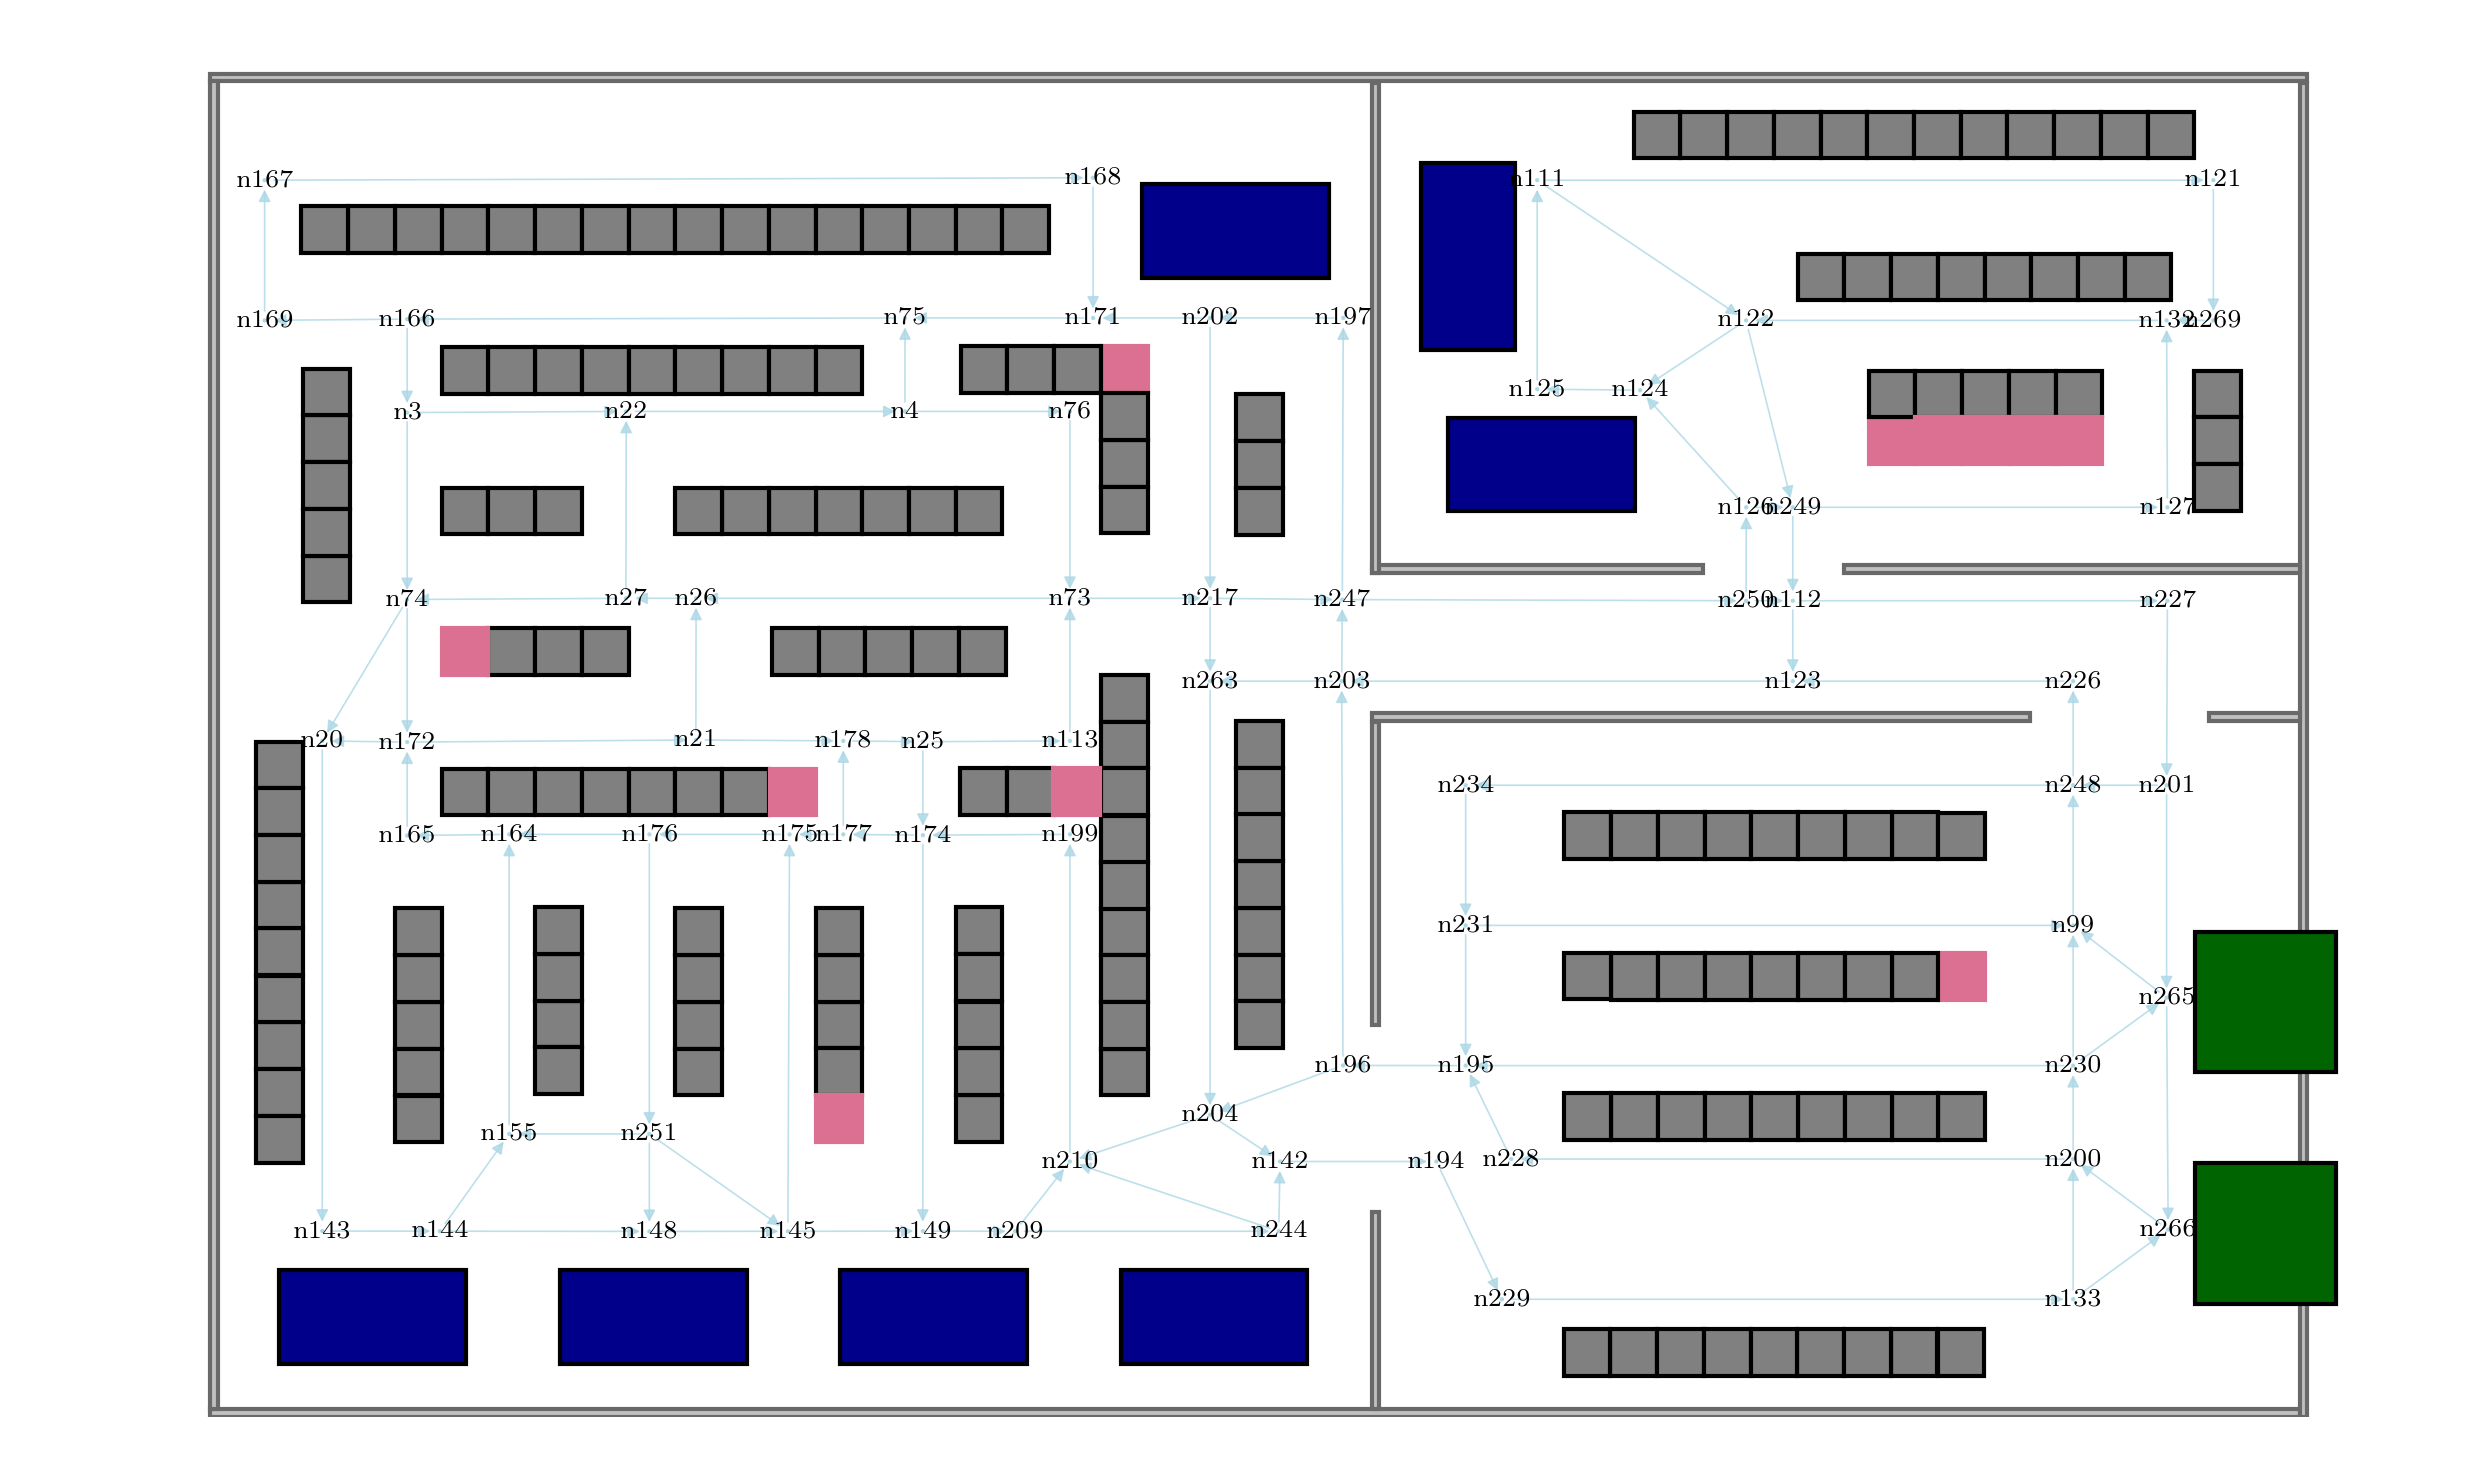

In [33]:
from itm_pythonfig.pythonfig import PythonFig

pf = PythonFig()
fig = pf.start_figure("latexnarrow", 12.88, 8.08)
# fig = plt.figure(figsize=(12.88, 8.08))
ax = plt.gca()
ax.invert_yaxis()

# positions from parsed GraphML
pos = {node: (data["x"], data["y"]) for node, data in G.nodes(data=True)}

# draw edges first (so rectangles appear on top)
nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edge_color="lightblue",
    alpha=0.8,
    arrowsize=3,
    width=0.2,
    node_size=5,
    min_source_margin=0,
    min_target_margin=0,
)

# draw rectangles for each node using width/height from GraphML
for node, data in G.nodes(data=True):
    if data.get("description") == "wall":
        draw_env_item(ax, data, color="silver", edgecolor="dimgray", zorder=0, node=node)
    if data.get("description") == "waypoint":
        draw_waypoint(ax, data, color="lightblue", node=node)
    if data.get("description") == "shelf":
        draw_env_item(ax, data, color="gray", node=node)
    if data.get("description") == "door":
        draw_env_item(ax, data, color="yellow", node=node)
    if data.get("description") == "machine":
        draw_env_item(ax, data, color="darkblue", node=node)
    if data.get("description") == "delivery":
        draw_env_item(ax, data, color="darkgreen", node=node)
    if data.get("description") == "charging station":
        draw_env_item(
            ax, data, color="palevioletred", edgecolor="palevioletred", node=node
        )

# ax.autoscale_view()
ax.set_aspect("equal")
plt.axis("off")
plt.show()

#### Save processed graph

In [34]:
nx.write_graphml(G, "../data/warehouse/Warehouse_preprocessed.graphml")

In [35]:
env_types = {}
env_types["shelves"] = shelves
env_types["waypoints"] = waypoints
env_types["delivery"] = delivery
env_types["machines"] = machines
env_types["doors"] = doors
env_types["charging_stations"] = charging_stations
env_types["walls"] = walls

In [36]:
import pickle

with open("../data/warehouse/warehouse_env_types.pkl", "wb") as f:
    pickle.dump(env_types, f)